<h1 style='text-align: right;'> تحليل الفيديو: </h1>

<h2 style='text-align: right;'>Meanshift و Camshift:</h2>

<p style='text-align: right; ' > 
رأينا فيما سبق التعرف القائم على الالوان , والان سنوضح خوارزمية أكثر تقدماً , Meanshift  ونسختها المطورة Camshift.
</p>

<h2 style='text-align: right;'> Meanshift</h2>

<p style='text-align: right;' > 
 الفكرة خلف ال **Meanshift ** بسيطة , افرض لدينا مجموعة نقاط مبعثرة بمستوي ونافذة على شكل دائرة قابلة للتحريك عيره , وتتلخص مسألتنا بتحريك هذه النافذة للحصول على أكبر كثافة (أكبر عدد ) للنقاط كما الصورة التالية :</p>

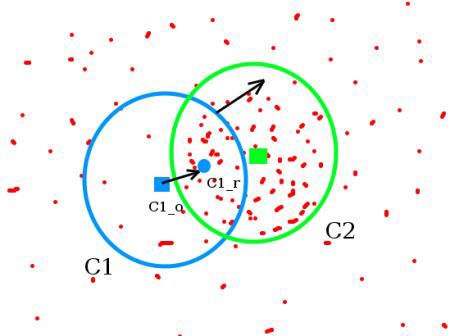

In [1]:
from IPython.display import Image

Image('images/figure_5.jpg')

للقيام بذلك علينا ايجاد مركز النقاط داخل الدائرة ( بحساب المتوسط) ثم نقل مركز الدائر ة ليتطابق معه وانشاء مكان جديد للدائرة , ومن ثم تتكرر العملية للدائرة الجديدة ونوجد المركز الجديد . وهكذا حتى لا يسفر التكرار عن تغيير كبير في مكان مركز الدائرة وعندها نتوقف.

وبذلك نحصل على النافذة ذات توزع البكسلات الاعظمي .

اذا سنقوم بتمرير هستوغرام مسقط خلفياً للصورة وموضع الهدف الاولي .
وعندها نحرك الهدف , فيتغير الهستوغرام , وعندها نستخدم خوارزمية ال Meanshift  لتحديد مكان النافذة الجديدة ذو الكثافة العليا .


## Meanshift في  OpenCV:

لتشغيل خوارزمية Meanshift  علينا أولاً تحديد الهدف وايجاد هستوغراماته , بحيث يمكننا اسقاطه عكسياً على كل اطار لحساب ال meanshift .

 ونحتاج أيضاً لاعطاء الموضع الاولي للنافذة . وبالنسبة للهستوغرام , سنأخذ فقط السطوع بالفضاء hsv  . وايضاً لتجنب الاخطاء سنبعد الضوء الخافت من الصورة عبر التابع
 
 **() cv2.inRange**  كالتالي:
 

In [1]:
import cv2
import numpy as np

import matplotlib.pyplot as plt

%matplotlib inline


In [3]:
cap = cv2.VideoCapture('videos/meanshift0.flv')

# take first frame of the video
ret,frame = cap.read()

# setup initial location of window
r,h,c,w = 480,150,100,70 # simply hardcoded the values
track_window = (c,r,w,h)

# set up the ROI for tracking
roi = frame[r:r+h, c:c+w]
hsv_roi = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
mask = cv2.inRange(hsv_roi, np.array((0., 60.,32.)), np.array((180.,255.,255.)))
roi_hist = cv2.calcHist([hsv_roi],[0],mask,[180],[0,180])
cv2.normalize(roi_hist,roi_hist,0,255,cv2.NORM_MINMAX)

# Setup the termination criteria, either 10 iteration or move by atleast 1 pt
term_crit = ( cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1 )

In [ ]:
while(1):
    ret ,frame = cap.read()
    
    if ret == True:
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        dst = cv2.calcBackProject([hsv],[0],roi_hist,[0,180],1)
        
        # apply meanshift to get the new location
        ret, track_window = cv2.meanShift(dst, track_window, term_crit)
        
        # Draw it on image
        x,y,w,h = track_window
        img2 = cv2.rectangle(frame, (x,y), (x+w,y+h), 255,2)
        
        cv2.imshow('img2',img2)
        
        k = cv2.waitKey(60) & 0xff
        if k == 27:
            break
        else:
            cv2.imwrite(chr(k)+".jpg",img2)
            
    else:
        break
        
cv2.destroyAllWindows()
cap.release()

 الفيديو في نهاية الصفحة سيوضح عمل هذا البرنامج بالشرح ..

## Camshift
هل لا حظت نتيجة التنفيذ الاخيرة لل Meanshift  هناك مشكلة , حجم النافذة المحددة للجسم يبقى ثابتاً لا يتغير , سواء اقترب الجسم ام ابتعد , ولذلك علينا جعل حجم النافذة يتغير تلقائياً حسب وضعية الجسم وتوجهه , وبذلك نجد الحل بالخوارزمية المدعوة Camshift .
(meanshift  المكيفة باستمرار )
والتي نشرت بورقة عام 1988  ل  Gary Bradsky

 وفيها تم تطبيق  meanshift  أولاً وبعد اتمامها نعدل قياس النافذة بعامل 
 $$ s = 2 . \sqrt{\frac{M_{00}}{256}}$$
 
وكذلك نحسب الدوران لانسب قطع ناقص محيط بها , ومجدداً نطبق meanshift مع القياس والموضع الجديدين للنافذة . وتستمر العملية حتى تحقيق دقة محددة .


## Camshift & OpenCV:
هذا مشابه تقريباً لتطبيق ال meanshift  إلا أنه يعطي المستطيل مدوراً مع البارامترات له , ولكن يجب تحديد الموضع البدائي للجسم :


In [ ]:
cap = cv2.VideoCapture('videos/meanshift0.flv')

# take first frame of the video
ret,frame = cap.read()

# setup initial location of window
r,h,c,w = 480,150,100,70 # simply hardcoded the values
track_window = (c,r,w,h)

# set up the ROI for tracking
roi = frame[r:r+h, c:c+w]
hsv_roi = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
mask = cv2.inRange(hsv_roi, np.array((0., 60.,32.)), np.array((180.,255.,255.)))
roi_hist = cv2.calcHist([hsv_roi],[0],mask,[180],[0,180])
cv2.normalize(roi_hist,roi_hist,0,255,cv2.NORM_MINMAX)

# Setup the termination criteria, either 10 iteration or move by atleast 1 pt
term_crit = ( cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1 )

In [ ]:
while(1):
    ret ,frame = cap.read()
    
    if ret == True:
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        dst = cv2.calcBackProject([hsv],[0],roi_hist,[0,180],1)
        
        # apply meanshift to get the new location
        ret, track_window = cv2.CamShift(dst, track_window, term_crit)
        
        # Draw it on image
        pts = cv2.boxPoints((track_window[:2],track_window[2:],ret))
        pts = np.int0(pts)
        img2 = cv2.polylines(frame,[pts],True, 255,2)
        
        cv2.imshow('img2',img2)
        
        k = cv2.waitKey(60) & 0xff
        if k == 27:
            break
        else:
            cv2.imwrite(chr(k)+".jpg",img2)
            
    else:
        break
        
cv2.destroyAllWindows()
cap.release()

النتائج بالفيديو بالنهاية 

## مراجع اضافية :

1. French Wikipedia page on Camshift. (The two animations are taken from here)

2. Bradski, G.R., “Real time face and object tracking as a component of a perceptual user interface,” Applications of Computer Vision, 1998. WACV ‘98. Proceedings., Fourth IEEE Workshop on , vol., no., pp.214,219, 19-21 Oct 1998



## تمارين :
* OpenCV  يأتي معه امثلة تفاعلية في python  لل camshift  , استخدمها , شغلها , وتفحصها..

## الحل :
بالفيديو أدناه.

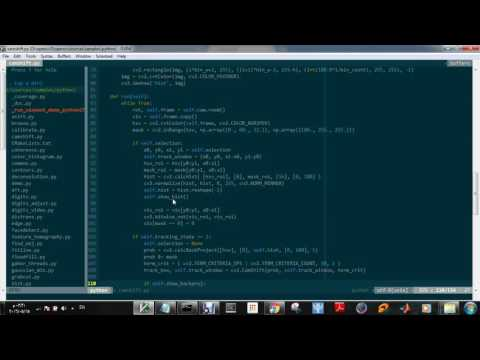

In [2]:
from IPython.display import YouTubeVideo

YouTubeVideo('X2syyyjyi1A')